# 量子カーネルt-SNEによるデータ可視化

本チュートリアルでは`scikit-quri`および`quri-parts`を使用して、量子カーネルt-SNEにより高次元データを可視化する方法を解説します。

## 量子カーネルt-SNEとは
量子カーネルt-SNEとは、量子カーネル法を応用した高次元データの可視化手法です。本手法を具体的に理解するために、ベースとなる「t-SNE」、それを拡張した「カーネルt-SNE」、そして本題である「量子カーネルt-SNE」について順を追って解説します。

### t-SNE
t-SNE (t-distributed Stochastic Neighbor Embedding) とは、高次元のデータを人間が理解できる2次元や3次元に圧縮して可視化するための教師なし学習アルゴリズムです。高次元空間でのデータ間の類似度（距離）を表す確率分布$p_{ij}$と、低次元空間でのデータ間の類似度を表す確率分布$q_{ij}$を用意し、これらの確率分布が近くなるように最適化を行います。

具体的には、高次元データ$\mathbb{x}_i$を低次元データ$\mathbb{y}_i$にマッピングすることを考えます。詳細な数式は省略しますが、高次元データ間（$\mathbb{x}_i$と$\mathbb{y}_j$）の類似度$p_{ij}$はガウス分布を用いて、低次元データ間（$\mathbb{y}_i$と$\mathbb{y}_j$）の類似度$q_{ij}$はt分布を用いて定義されます。このとき以下のステップで高次元データの可視化を行います
1. 低次元データ$\mathbb{y}_i$の初期位置をランダムに決める
2. 類似度$p_{ij}$と$q_{ij}$を計算する
3. 以下のKullback-Leibler (KL) ダイバージェンスで定義されるコスト関数$C$を最小化するように低次元データ$\mathbb{y}_i$の配置を最適化する
$$ C=\sum_{i, j}p_{ij}\log{\frac{p_{ij}}{q_{ij}}} $$
4. 最適化された低次元データ$\mathbb{y}_i$をプロットすることで、高次元データ$\mathbb{x}_i$の可視化が完了する

### カーネルt-SNE
通常のt-SNEでは、後から新しい未知のデータを追加したい場合、最初から計算し直す必要があります。カーネルt-SNEはそのデメリットを補い、未知のデータへの対応を可能にした手法です。

具体的には、訓練データセット$\{\mathbb{x}_i\}$が与えられたとき、高次元ベクトル$\mathbb{x}$を低次元の$d$次元データ$\mathbb{y}$に、以下のようにマッピングすることを考えます。
$$ \mathbb{y}(x)=\sum_i \alpha_i K(\mathbb{x}_i, \mathbb{x}) $$
ここで$K(\mathbb{x}_i, \mathbb{x})$はカーネル関数と呼ばれ、代表的なものに多項式カーネルやRBFカーネルなどがあります。$\mathbb{\alpha}_i\in \mathbb{R}^d$は訓練パラメータで、通常のt-SNEと同じKLダイバージェンスで定義されたコスト関数を最小化するように最適化されます。これにより未知のデータを含む高次元ベクトルを低次元ベクトルにマッピングし、可視化することが可能になります。

### 量子カーネルt-SNE
量子カーネルt-SNEは、カーネルt-SNEにおけるカーネル関数として量子カーネルを用いるという手法です。量子カーネルを計算するには、まず古典データ$x$の情報を埋め込んだ量子回路$U(x)$によって、$x$を量子状態$|\psi(x)⟩$にエンコードします。 そして2つのデータ$x$, $x'$間の量子カーネルは以下のように定義されます。
$$K(x,x')=∣⟨\psi(x)∣\psi(x')⟩∣^2$$

↓必要？

In [2]:
from pathlib import Path
import sys

sys.path.append(str(Path().resolve().parent))
import os

os.environ["OMP_NUM_THREADS"] = "1"
%env OMP_NUM_THREADS=1

env: OMP_NUM_THREADS=1


## 本チュートリアルのゴール

本チュートリアルでは、手書き数字データ（64次元データ）セットを2次元空間にマッピングし、そのクラス（0~9の数字）ごとの分布を可視化するというタスクに取り組みます。

具体的には以下のステップで進めます。
1. 手書き数字データセットを読み込む
2. 量子回路のqubit数に合わせるため、主成分分析を用いてデータの次元を圧縮する
3. データを回転ゲートの回転角として埋め込めるようにデータを正規化する
4. `scikit-quri`を用いてモデルを学習させる
5. 学習済みのモデルを使って訓練データを2次元空間にマッピングし、クラスごとの分布をプロットして可視化する
6. 未知のテストデータに対しても同様に可視化してモデルを評価する

## データセットの準備
まず、`scikit-learn`に含まれている手書きデータセットを読み込み、訓練用とテスト用に分割します。`X`は$8\times 8$ピクセルの画像を1列（64次元）に並べたデータで、`Y`は0~9のクラスを表すラベルです。量子カーネルt-SNEは教師なし学習なので学習に`Y`は使われませんが、ここではプロット時の色分けに使用します。

In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import StratifiedKFold

X, Y = load_digits(return_X_y=True)
print(f"{X.shape=}")
print(f"{Y.shape=}")
X = X / 16.0

skf = StratifiedKFold()
for tr_index, te_index in skf.split(X, Y):
    break

X_train = X[tr_index]
X_test = X[te_index]
y_train = Y[tr_index]
y_test = Y[te_index]

print(f"{X_train.shape=}")

X.shape=(1797, 64)
Y.shape=(1797,)
X_train.shape=(1437, 64)


## 次元圧縮

`X`を量子回路に埋め込むためにデータの次元数を削減します。 元のデータは64次元ですが、本チュートリアルで使用する量子回路（12qubits）に合わせて、主成分分析を用いて 12次元に圧縮します。

In [2]:
from sklearn.decomposition import PCA

n_features = 12

pca = PCA(n_components=n_features)
pca.fit(X_train)
X_train = pca.transform(X_train)
X_test = pca.transform(X_test)
print(f"{X_train.shape=}")

X_train.shape=(1437, 12)


## データの正規化

主成分分析で圧縮したデータを、量子ゲート（回転ゲート）の回転角として入力できるように正規化します。ここでは`MinMaxScaler`を用い、すべての特徴量が0から$\pi$/2の範囲に収まるように変換します。

In [3]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler((0, np.pi / 2))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 学習と訓練データの可視化

前処理したデータを用いて、量子カーネルt-SNEモデルを学習させます。

まず、データを量子状態へエンコードするための量子回路$U(x)$を定義します。ここでは`scikit-quri`の`LearningCircuit`を用い、12次元のデータを12量子ビットの回転角（RX、RYゲート）として埋め込みます。

In [4]:
from scikit_quri.circuit import LearningCircuit
from numpy.typing import NDArray
from quri_parts.circuit import H, CZ

n_qubits = 12

def create_quantum_circuit():
    depth = 1

    qc = LearningCircuit(n_qubits)

    def preprocess_x(x: NDArray[np.float64], index: int) -> float:
        xa = x[index % len(x)]
        return min(1, max(-1, xa))

    for i in range(n_qubits):
        qc.add_gate(H(i))
    for d in range(depth):
        for i in range(n_qubits):
            qc.add_input_RY_gate(i, lambda x, i=i: preprocess_x(x, i))
        for i in range(n_qubits):
            qc.add_input_RX_gate(i, lambda x, i=i: preprocess_x(x, i))
        if d < depth - 1:
            for i in range(n_qubits):
                qc.add_gate(CZ(i, (i + 1) % n_qubits))
    return qc

量子カーネルt-SNEモデルの構築と学習には`scikit-quri`の`quantum_kernel_tsne`クラスを使用します。`init`メソッドを使用してモデルを初期化し、`train`メソッドにより学習を開始します。

学習は以下のように行われます。

1. 高次元の訓練データを量子回路に入力して量子状態を作成し、ガウス分布からデータ間の類似度$p_{ij}$を計算する
2. 訓練データ間の量子カーネルを計算し、ランダムに初期化されたパラメータ$\mathbb{\alpha}_i$を用いて低次元（2次元）データを生成する。
3. t分布を用いて低次元データの類似度を計算する
4. 高次元データと低次元データの類似度からコスト関数（KLダイバージェンス）を計算する
5. 上記の手順を繰り返してコスト関数を最小化するように$\mathbb{\alpha}_i$を最適化する。

またここでは`train`メソッドの過程で、学習前の$\mathbb{\alpha}_i$を用いたマッピングで低次元データをプロットしたものと、学習後の$\mathbb{\alpha}_i$を用いたマッピングで低次元データをプロットしたものを示しています（`y_train`を用いて数字ごとに色分けしています）。

calculating p_ij
 1436/1437
calculating fidelity
 1436/1437elapsed time:6.754491083993344


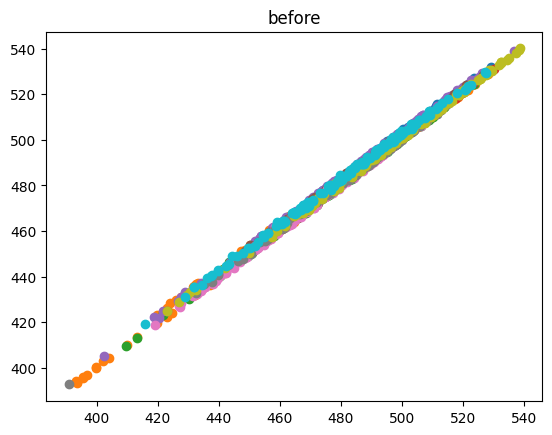

 iter=5000 loss=np.float64(2.615322993473359) message: Maximum number of function evaluations has been exceeded.
 success: False
  status: 1
     fun: 2.6153357328314675
       x: [-7.256e+02 -1.493e+02 ...  5.936e-01  9.263e-01]
     nit: 0
   direc: [[ 1.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]]
    nfev: 5000


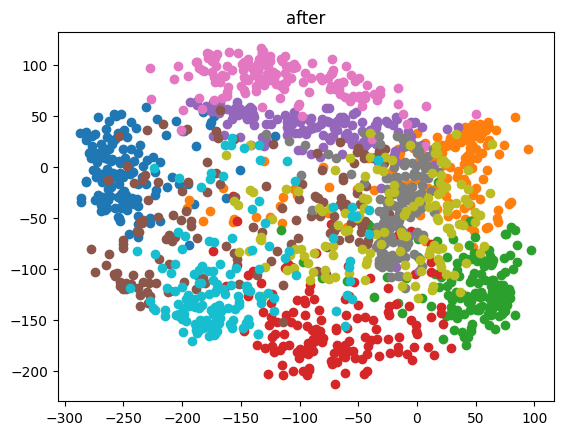

In [ ]:
from scikit_quri.qnn.kernel_tsne import quantum_kernel_tsne


qk_tsne = quantum_kernel_tsne(max_iter=5000)

qk_tsne.init(create_quantum_circuit, [])
qk_tsne.train(X_train, y_train, method="Powell") # y_trainはプロットの色分けに使っているだけ



## テストデータ

最後に、学習には使用していないテストデータを可視化して、モデルの汎化性能を評価します。`transform`メソッドを実行すると、テストデータと学習データ間の量子カーネルが計算され、それに基づいてテストデータを低次元データにマッピングしたものが得られます。プロットでは`y_test`を用いて数字ごとに色分けしています。

 359/360


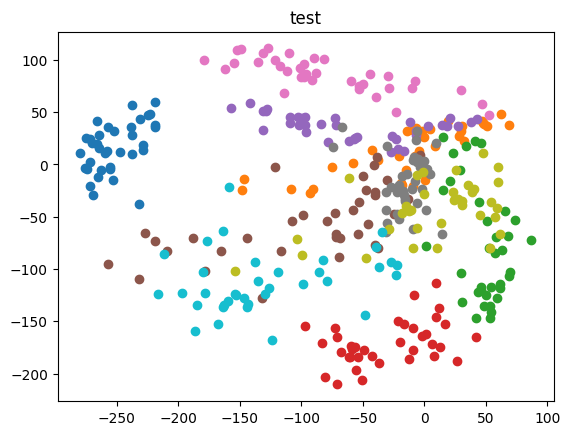

In [6]:
pred_y = qk_tsne.transform(X_test)
qk_tsne.plot(pred_y, y_test, "test")

↓必要？

In [3]:
from scipy.spatial import distance

# M = np.random.randint(0, 10, (5, 2))
M = np.array([[np.random.rand()] for _ in range(5)])
cdist = distance.cdist(M, M)
print(cdist)

[[0.         0.41400003 0.27691925 0.07854943 0.03574476]
 [0.41400003 0.         0.13708079 0.49254947 0.44974479]
 [0.27691925 0.13708079 0.         0.35546868 0.312664  ]
 [0.07854943 0.49254947 0.35546868 0.         0.04280468]
 [0.03574476 0.44974479 0.312664   0.04280468 0.        ]]


In [4]:
print(f"{M=}")
x1_norm = np.sum(M**2, axis=1)[:, np.newaxis]
print(f"{x1_norm=}")
x1_pad = np.ones_like(x1_norm)
print(f"{x1_norm.shape=}")
print(f"{x1_pad.shape=}")
print(f"{(-2*M).shape=}")
# phi = np.concatenate((-2*M,np.sum(M**2,axis=1),np.ones((len(M),1))))
psi = np.concatenate((-2 * M, x1_norm, x1_pad), axis=1)
print(psi)

M=array([[0.43993002],
       [0.02592999],
       [0.16301078],
       [0.51847946],
       [0.47567478]])
x1_norm=array([[0.19353842],
       [0.00067236],
       [0.02657251],
       [0.26882095],
       [0.2262665 ]])
x1_norm.shape=(5, 1)
x1_pad.shape=(5, 1)
(-2*M).shape=(5, 1)
[[-8.79860042e-01  1.93538423e-01  1.00000000e+00]
 [-5.18599739e-02  6.72364224e-04  1.00000000e+00]
 [-3.26021550e-01  2.65725128e-02  1.00000000e+00]
 [-1.03695891e+00  2.68820946e-01  1.00000000e+00]
 [-9.51349558e-01  2.26266495e-01  1.00000000e+00]]


In [5]:
x2_norm = np.sum(M**2, axis=1)[:, np.newaxis]
x2_pad = np.ones_like(x2_norm)
phi = np.concatenate((M, x2_pad, x2_norm), axis=1)
print(phi)

[[4.39930021e-01 1.00000000e+00 1.93538423e-01]
 [2.59299870e-02 1.00000000e+00 6.72364224e-04]
 [1.63010775e-01 1.00000000e+00 2.65725128e-02]
 [5.18479456e-01 1.00000000e+00 2.68820946e-01]
 [4.75674779e-01 1.00000000e+00 2.26266495e-01]]


In [6]:
D_2 = psi @ phi.T
D_2 = np.sqrt(D_2)
print(D_2)

[[0.         0.41400003 0.27691925 0.07854943 0.03574476]
 [0.41400003 0.         0.13708079 0.49254947 0.44974479]
 [0.27691925 0.13708079 0.         0.35546868 0.312664  ]
 [0.07854943 0.49254947 0.35546868 0.         0.04280468]
 [0.03574476 0.44974479 0.312664   0.04280468 0.        ]]


In [7]:
np.isclose(D_2, cdist)

array([[ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True]])

In [8]:
# import torch
# from inspect import getsource,getfile
# M = np.array([[np.random.rand()] for _ in range(6) ])
# M_t = torch.tensor(M,dtype=torch.float64,requires_grad=True)
# cdist = torch.cdist(M_t,M_t)
# print(f"{getfile(cdist.grad_fn)=}")
# print(f"{dir(cdist.grad_fn)=}")
# s = torch.sum(cdist)
# s.backward()
# print(f"{M_t.grad=}")

In [9]:
# grad